In [1]:
import os, json, time
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import imageio
from tqdm import tqdm, trange

np.random.seed(0) # 确保每次运行代码时，生成的随机数序列是一样的

/tmp/ipykernel_49573/120412921.py:19: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  imgs.append(imageio.imread(fname))


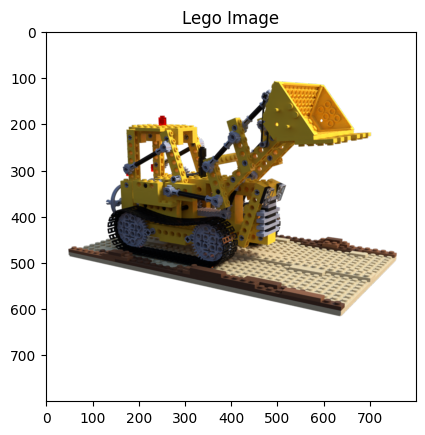

In [2]:
# 读取数据
splits = ['train', 'val', 'test']
datadir = '../../images/lego'
metas = {}
for s in splits:
    with open(os.path.join(datadir, 'transforms_{}.json'.format(s)), 'r') as fp: # with open = try: finally:
        metas[s] = json.load(fp)

all_images = []
all_poses = []
counts = [0]
for s in splits:
    meta = metas[s]
    imgs = []
    poses = []
    camera_angle_x = float(meta['camera_angle_x'])
    for frame in meta['frames'][::]:
        fname = os.path.join(datadir, frame['file_path'] + '.png')
        imgs.append(imageio.imread(fname))
        poses.append(np.array(frame['transform_matrix']))
        
    imgs = (np.array(imgs) / 255.).astype(np.float32)
    H, W = imgs[0].shape[0:2]
    focal = 0.5 * W / np.tan(0.5 * camera_angle_x)
    poses = np.array(poses).astype(np.float32)
    counts.append(counts[-1] + imgs.shape[0])
    all_images.append(imgs)
    all_poses.append(poses)
    K = np.array([
        [focal, 0, 0.5 * W],
        [0, focal, 0.5 * H],
        [0, 0, 1]
    ])

imgs = np.concatenate(all_images, 0)
poses = np.concatenate(all_poses, 0)

plt.figure('lego')
plt.imshow(imgs[10])
plt.title('Lego Image')
plt.show()


In [ ]:
# 生成射线
def get_rays_np(H, W, K, c2w): 
    i, j = np.meshgrid(np.arange(W, dtype=np.float32), np.arange(H, dtype=np.float32), indexing='xy')
    dirs = np.stack([(i - K[0][2]) / K[0][0], -(j-K[1][2])/K[1][1], -np.ones_like(i)], -1) # 相机坐标系下的射线方向 [H,W,3]
    rays_d = np.sum(dirs[..., np.newaxis, :] * c2w[:3, :3], -1) # 旋转光线到世界坐标系下 [H,W,3]
    rays_o = np.broadcast_to(c2w[:3,-1], np.shape(rays_d)) # 将相机光心平移到世界坐标系 [H,W,3]
    return rays_o, rays_d

rays = np.stack([get_rays_np(H, W, K, p) for p in poses[:,:3,:4]], 0) # [N, ro+rd, H, W, 3]
    

: 

In [ ]:
imgs_rgb = imgs[...,:3]
rays_rgb = np.concatenate([rays, imgs_rgb[:,None]], 1) # [N, ro+rd+rgb, H, W, 3]
rays_rgb = np.transpose(rays_rgb, [0,2,3,1,4])
i_train = 100
rays_rgb_train = np.stack([rays_rgb[i] for i in range(i_train)], 0)
rays_rgb_train = np.reshape(rays_rgb_train, [-1,3,3]).astype(np.float32)
np.random.shuffle(rays_rgb_train)
